# IE 7615 Project 1

## Study Group 3
**Name:** Anika Mamidwar  

**Name:** Kevin Fei  

**Name:** Vidhi Deepakbhai Patel

**Name:** Annapurna Mandalika





## 1.0 Setup

In [ ]:
import os, re, json, random, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image

SEED = 42 # Use this seed if reproducing
IMG_SIZE = (224,224)
BATCH_SIZE = 32

DATA_VERSION = "v2"

PROJECT = Path("/content/drive/MyDrive/IE7615_project_1") # group Google Drive folder
DATASET_ZIP = PROJECT / f"dataset_{DATA_VERSION}.zip"   # frozen snapshot of dataset at 2026-10-01 12pm
LOCAL_DATA = Path(f"/content/data_{DATA_VERSION}") # fast temporary copy
REGISTRY_CSV = PROJECT / f"registry_{DATA_VERSION}.csv" # Google Sheets registry file

# For reproducibility
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

FOLDER_ID    = re.compile(r"OBJ\d{3}", re.IGNORECASE) # ID lives in the folder name
FILE_PATTERN = re.compile(r"^(.+?)_(bg_?)?(\d+)$", re.IGNORECASE)   # any prefix, optional bg / bg_, number

# Unseen-environment holdout: kept out of train/val/test, reported separately
UNSEEN = {("OBJ042", n) for n in range(33, 42)} # OBJ042_033 - OBJ042_041; just want to see how the system behaves for these

# Keeping the splits consistent across runs
SPLITS_CSV = PROJECT / f"splits_{DATA_VERSION}.csv"
FORCE_RESPLIT = False # only set True if you deliberately want a new split
CLASS_NAMES_JSON = PROJECT / f"class_names_{DATA_VERSION}.json"

MODELS_DIR  = PROJECT / f"models_{DATA_VERSION}"      # best checkpoint per experiment
RESULTS_CSV = PROJECT / f"results_{DATA_VERSION}.csv" # one row per experiment, appended automatically

# Files deliberately left out of the dataset (documented in the data-issues notes)
EXCLUDE = {"OBJ028_032(1).jpg"}   # duplicate download copy of OBJ028_032.jpg

print(tf.__version__, tf.config.list_physical_devices("GPU")) # Making sure GPU is attached

2.20.0 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive

drive.mount("/content/drive")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

assert DATASET_ZIP.exists(), f"Snapshot not found at {DATASET_ZIP}"
PROJECT.mkdir(parents=True, exist_ok=True)

# Unzip once per session (skip if already unzipped in current runtime)
if not LOCAL_DATA.exists():
  shutil.unpack_archive(DATASET_ZIP, LOCAL_DATA)

# Repair oversized images (OBJ0222) in the local copy
def repair_oversized(min_bytes=1_000_000):
    """Downscale any oversized JPEG (e.g. OBJ022's 16128×16128 files) to IMG_SIZE, in the local copy only."""
    old_limit = Image.MAX_IMAGE_PIXELS
    Image.MAX_IMAGE_PIXELS = None              # trusted classmate files; limit restored below
    fixed = []
    try:
        for p in LOCAL_DATA.rglob("*"):
            if p.suffix.lower() not in {".jpg", ".jpeg"} or p.stat().st_size < min_bytes:
                continue                       # normal files are ~16 KB, so this skips almost everything
            with Image.open(p) as im:
                original = im.size
                im.draft("RGB", (IMG_SIZE[0] * 2, IMG_SIZE[1] * 2))   # JPEG decodes at reduced scale: fast, low memory
                im.convert("RGB").resize(IMG_SIZE, Image.LANCZOS).save(p, "JPEG", quality=95)
            fixed.append((p.relative_to(LOCAL_DATA), original))
    finally:
        Image.MAX_IMAGE_PIXELS = old_limit
    return fixed

fixed = repair_oversized()
print(f"Repaired {len(fixed)} oversized images", f"(e.g. {fixed[0][0]} was {fixed[0][1]})" if fixed else "")

# Check files per student folder
for sub in sorted(p for p in LOCAL_DATA.rglob("*") if p.is_dir()):
  n = len([f for f in sub.iterdir() if f.is_file()])
  if n:
    print(f"{sub.name}: {n} files")

# Check files that aren't .jpg
others = [p for p in LOCAL_DATA.rglob("*") if p.is_file() and p.suffix.lower() not in {".jpg", ".jpeg"}]
print(f"\nNon-JPG files: {len(others)}")
for p in others[:20]:
  print("  ", p.relative_to(LOCAL_DATA))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repaired 0 oversized images 
images_OBJ001: 100 files
images_OBJ002: 100 files
images_OBJ003: 100 files
images_OBJ004: 100 files
images_OBJ005: 108 files
images_OBJ006: 100 files
images_OBJ007: 100 files
images_OBJ008: 100 files
images_OBJ009: 106 files
images_OBJ010: 100 files
images_OBJ011: 100 files
images_OBJ012: 100 files
images_OBJ013: 100 files
images_OBJ014: 100 files
images_OBJ015: 100 files
images_OBJ016: 100 files
images_OBJ017: 113 files
images_OBJ018: 100 files
images_OBJ019: 100 files
images_OBJ020: 100 files
images_OBJ021: 100 files
images_OBJ022: 100 files
images_OBJ023: 100 files
images_OBJ024: 100 files
images_OBJ025: 100 files
images_OBJ026: 100 files
images_OBJ027: 100 files
images_OBJ028: 101 files
images_OBJ029: 100 files
images_OBJ030: 100 files
images_OBJ031: 100 files
images_OBJ032: 100 files
images_OBJ033: 100 files
images_OBJ034: 10

## 2.0 Data validation and pre-processing

A few issues were observed during our EDA when we reconciled the Google Sheets registry file with the downloaded snapshot of the Shared Google Drive Folder (`dataset_v1.zip` - *snapshot taken at 2026-10-01 12pm*).

*   Only 38 folders in the Drive, 70+ students claimed "submitted" in the Google Sheets.
*   OBJ060 used unpadded numbers.
*   OBJ046 and OBJ054 used object names instead of IDs.
*   Folder names vary, so the ID is taken from the folder name.
*   OBJ004 and OBJ012 have no backgrounds.
*   Three registry IDs are duplicates.
*   Duplicated IDs: OBJ022, OBJ062, OBJ073.
*   OBJ124 has more than 100 images.
-------
After the dataset (`dataset_v2.zip` - *snapshot taken at 2026-10-02 9pm*) was updated and finalized, many of the issues mentioned above were resolved. The remaining issues and our pre-processing methodology is documented below:

*   OBJ023 had an oversized background image (2597x2568) which was downscaled after unzipping. So we ensured our pipeline checks the file contents and not just the names.
*   The background images for OBJ013 did not follow the naming convention. Our parser takes the ID class from the folder name and is tolerant of filename variations.
*   There was a duplicate image (`OBJ_032(1).jpg`) which was excluded via the documented `EXCLUDE` list above.
*   Stray system files (`.DS_Store` and a `.claude` folder) were ignored by our pipleine.
*   The number of photos for a few objects were over or under 100 with a varying number of background images. Hence, we created a "no object" class and used the class weights to compensate during training (0.25 for "no object" and about 1.0 for objects).


We also decided to use an anonymized registry (removing any personal identification details) to map the object IDs to their names for better interpretability later on. We then proceeded to **only use what we have in the snapshot of the Google Drive folder and this dataset is stored as `dataset_v2.zip` for the remainder of this notebook.**

Therefore, we are adding some validation checks below.

In [ ]:
from collections import Counter

bad, per_class = [], Counter()
for p in LOCAL_DATA.rglob("*"):
  if p.suffix.lower() not in {".jpg", ".jpeg"}:
    continue
  fid = FOLDER_ID.search(p.parent.name)
  m = FILE_PATTERN.match(p.stem)
  if fid is None or m is None:
    bad.append(p.relative_to(LOCAL_DATA))
    continue
  per_class[(fid.group().upper(), "bg" if m.group(2) else "obj")] += 1

print(f"Unparseable files: {len(bad)}")
for p in bad[:20]: print("  ", p)

ids = {k[0] for k in per_class}
print(f"\nClasses found: {len(ids)}")
print(f"Total object images: {sum(v for k, v in per_class.items() if k[1] == 'obj')}")
print(f"Total background images: {sum(v for k, v in per_class.items() if k[1] == 'bg')}")

unusual = {k: v for k, v in per_class.items() if (k[1] == "obj" and v != 95) or (k[1] == "bg" and v != 5)}
print(f"\nStudents not at 95 object + 5 background: {unusual}")

Unparseable files: 1
   IE7615 Deep Learning for AI/images_OBJ028/OBJ028_032(1).jpg

Classes found: 73
Total object images: 6957
Total background images: 385

Students not at 95 object + 5 background: {('OBJ053', 'obj'): 90, ('OBJ053', 'bg'): 10, ('OBJ009', 'bg'): 11, ('OBJ014', 'obj'): 93, ('OBJ014', 'bg'): 7, ('OBJ005', 'obj'): 99, ('OBJ005', 'bg'): 9, ('OBJ051', 'obj'): 105, ('OBJ013', 'obj'): 94, ('OBJ013', 'bg'): 6, ('OBJ069', 'obj'): 93, ('OBJ069', 'bg'): 7, ('OBJ063', 'obj'): 94, ('OBJ063', 'bg'): 6, ('OBJ004', 'obj'): 100, ('OBJ049', 'obj'): 99, ('OBJ049', 'bg'): 6, ('OBJ025', 'bg'): 6, ('OBJ025', 'obj'): 94, ('OBJ017', 'obj'): 106, ('OBJ017', 'bg'): 7}


In [ ]:
def file_type(path):
    """Identify the real format from the first bytes, regardless of the extension."""
    with open(path, "rb") as f:
        head = f.read(12)
    if head[:3] == b"\xff\xd8\xff":          return "jpeg"
    if head[:8] == b"\x89PNG\r\n\x1a\n":     return "png"
    if head[4:8] == b"ftyp":                 return "heic"
    if head[:4] == b"RIFF":                  return "webp"
    return f"unknown {head[:4]}"

problems = []
for p in sorted(LOCAL_DATA.rglob("*")):
    if p.name in EXCLUDE:
        continue
    if p.suffix.lower() not in {".jpg", ".jpeg"}:
        continue
    kind = file_type(p)
    try:
        tf.io.decode_jpeg(tf.io.read_file(str(p)), channels=3)
        decodes = True
    except tf.errors.InvalidArgumentError:
        decodes = False
    if kind != "jpeg" or not decodes:
        problems.append({"path": str(p.relative_to(LOCAL_DATA)), "real_type": kind, "decodes": decodes})

print(f"Problem files: {len(problems)}")
pd.DataFrame(problems)

Problem files: 0


""


## 3.0 One-time: manifest & split data

In [ ]:
rows = []
for p in sorted(LOCAL_DATA.rglob("*")):
    if p.name in EXCLUDE:
      continue
    if p.suffix.lower() not in {".jpg", ".jpeg"}:
      continue
    fid = FOLDER_ID.search(p.parent.name)
    m = FILE_PATTERN.match(p.stem)
    if fid is None or m is None:
      raise ValueError(f"Unparseable file: {p}") # validation passed, so this should never fire
    owner = fid.group().upper()
    is_bg = m.group(2) is not None
    rows.append({
      "path":    str(p.relative_to(LOCAL_DATA)), # relative, so it works on any runtime
      "owner":   owner, # which student's folder
      "is_bg":   is_bg,
      "img_num": int(m.group(3)),
      "label":   "no_object" if is_bg else owner,
    })
df = pd.DataFrame(rows)

# Duplicate check: the same student, type, and number appearing twice (e.g. OBJ124's extras)
dupes = df[df.duplicated(["owner", "is_bg", "img_num"], keep=False)]
print(f"Duplicate (owner, type, number) entries: {len(dupes)}")
print(dupes.sort_values(["owner", "img_num"]).head(20))

print(f"\nImages: {len(df)} | Classes: {df['label'].nunique()}")
print(df["label"].value_counts().describe())

Duplicate (owner, type, number) entries: 0
Empty DataFrame
Columns: [path, owner, is_bg, img_num, label]
Index: []

Images: 7342 | Classes: 74
count     74.000000
mean      99.216216
std       33.739238
min       90.000000
25%       95.000000
50%       95.000000
75%       95.000000
max      385.000000
Name: count, dtype: float64


In [ ]:
import zlib

if SPLITS_CSV.exists() and not FORCE_RESPLIT:
    print(f"{SPLITS_CSV.name} exists - skipping split. Set FORCE_RESPLIT = True to regenerate.")
else:
  BLOCK, VAL_FRAC, TEST_FRAC = 5, 0.15, 0.15
  df["block"] = (df["img_num"] - 1) // BLOCK # 1–5 → block 0, 6–10 → block 1, ...
  df["split"] = ""

  # 1. Unseen-environment holdout
  unseen = [(o, n) in UNSEEN and not b for o, n, b in zip(df["owner"], df["img_num"], df["is_bg"])]
  df.loc[unseen, "split"] = "unseen"

  def class_rng(key):
    """Seed derived from the key itself, so adding new classes never reshuffles existing ones."""
    return np.random.default_rng(SEED + zlib.crc32(key.encode()))

  def assign(units, rng):
    """Shuffle units and return {unit: split} with ~15% val, ~15% test, rest train."""
    units = np.array(sorted(units))
    rng.shuffle(units)
    n_val = max(1, round(VAL_FRAC * len(units)))
    n_test = max(1, round(TEST_FRAC * len(units)))
    return {u: "test" if i < n_test else "val" if i < n_test + n_val else "train"
            for i, u in enumerate(units)}

  # 2. Object images: split each class by blocks of consecutive shots
  for owner, g in df[(df["split"] == "") & ~df["is_bg"]].groupby("owner"):
    mapping = assign(g["block"].unique(), class_rng(owner))
    df.loc[g.index, "split"] = g["block"].map(mapping)

  # 3. Background images: split by student
  bg = df[(df["split"] == "") & df["is_bg"]]
  mapping = assign(bg["owner"].unique(), class_rng("no_object"))
  df.loc[bg.index, "split"] = bg["owner"].map(mapping)

  assert (df["split"] != "").all()
  class_names = sorted(df["label"].unique())

  df.drop(columns="block").to_csv(SPLITS_CSV, index=False)
  with open(CLASS_NAMES_JSON, "w") as f:
    json.dump(class_names, f, indent=2)

  print(df["split"].value_counts())
  print(pd.crosstab(df["label"], df["split"]).loc[["OBJ042", "no_object"]])

split
train     5027
test      1153
val       1153
unseen       9
Name: count, dtype: int64
split      test  train  unseen  val
label                              
OBJ042       15     56       9   15
no_object    58    267       0   60


As a personal test, our group decided to take OBJ042 which was a red mouth guard case in a completely "unseen-environment". Essentially, we took 9 images of this object with a background completely different to the 5 background images in the folder. These 9 images were part of a separate hold-out set that we used to test our model's performance. We did this because we wanted to see how well our final CNN model could classify our object in this new scene.

## 4.0 Load the frozen split

In [ ]:
# Load the frozen split
df = pd.read_csv(SPLITS_CSV)
with open(CLASS_NAMES_JSON) as f:
    class_names = json.load(f)
label_to_idx = {c: i for i, c in enumerate(class_names)}
NUM_CLASSES = len(class_names)
print(f"{len(df)} images | {NUM_CLASSES} classes | {df['split'].value_counts().to_dict()}")

# tf.data loaders
def make_ds(split, shuffle=False):
    """Return a batched tf.data.Dataset of (raw 0–255 image, class index) for one split."""
    sub = df[df["split"] == split]
    paths = [str(LOCAL_DATA / p) for p in sub["path"]]
    labels = sub["label"].map(label_to_idx).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(sub), seed=SEED, reshuffle_each_iteration=True)

    def load(path, label):
        img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        return img, label

    return (ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
              .batch(BATCH_SIZE)
              .prefetch(tf.data.AUTOTUNE))

train_ds  = make_ds("train", shuffle=True)
val_ds    = make_ds("val")
test_ds   = make_ds("test")
unseen_ds = make_ds("unseen")

# Class weights (training split only)
train_counts = df[df["split"] == "train"]["label"].value_counts()
n_train = train_counts.sum()
CLASS_WEIGHTS = {label_to_idx[c]: n_train / (NUM_CLASSES * n) for c, n in train_counts.items()}
print(f"no_object weight: {CLASS_WEIGHTS[label_to_idx['no_object']]:.2f} | "
      f"OBJ042 weight: {CLASS_WEIGHTS[label_to_idx['OBJ042']]:.2f}")

7342 images | 74 classes | {'train': 5027, 'test': 1153, 'val': 1153, 'unseen': 9}
no_object weight: 0.25 | OBJ042 weight: 1.21


Cell below cleans up reconciles the object IDs with their names for easier interpretability. It also cleans up the naming by removing trailing spaces. Duplicate IDs are overwitten by the IDs actually in the `dataset_v2.zip` folder. The assert checks that every one of our classes has a name. Additionally, the object names also include the ID next to them so we can remove any doubt in the confusion matrices (we have multiple watches and power banks in the dataset).

In [ ]:
# Readable class names for plots and reports (training still uses IDs)
reg = pd.read_csv(REGISTRY_CSV)
reg.columns = reg.columns.str.strip()                                   # header has "OBJECT_ID " with a space
reg = reg.apply(lambda s: s.str.strip() if s.dtype == object else s)    # trailing spaces in values
reg = reg.dropna(subset=["OBJECT_ID", "OBJECT_NAME"])

dup_ids = reg[reg["OBJECT_ID"].duplicated(keep=False)]
assert dup_ids.empty, f"Registry has duplicate IDs:\n{dup_ids[['OBJECT_ID', 'OBJECT_NAME']]}"

id_to_name = reg.set_index("OBJECT_ID")["OBJECT_NAME"].to_dict()
id_to_name["no_object"] = "No object"

missing = [c for c in class_names if c not in id_to_name]
assert not missing, f"No registry name for: {missing}"

# Same order as class_names, so DISPLAY_NAMES[i] is the readable name for class index i
DISPLAY_NAMES = [id_to_name[c] if c == "no_object" else f"{id_to_name[c]} ({c})" for c in class_names]
print(DISPLAY_NAMES[:5], "...")

['Basketball (OBJ001)', 'water bottle (OBJ002)', 'NoteBook (OBJ003)', 'Toy Car (OBJ004)', 'Computer mouse (OBJ005)'] ...


Sanity check below to make sure the images and labels have been loaded correctly

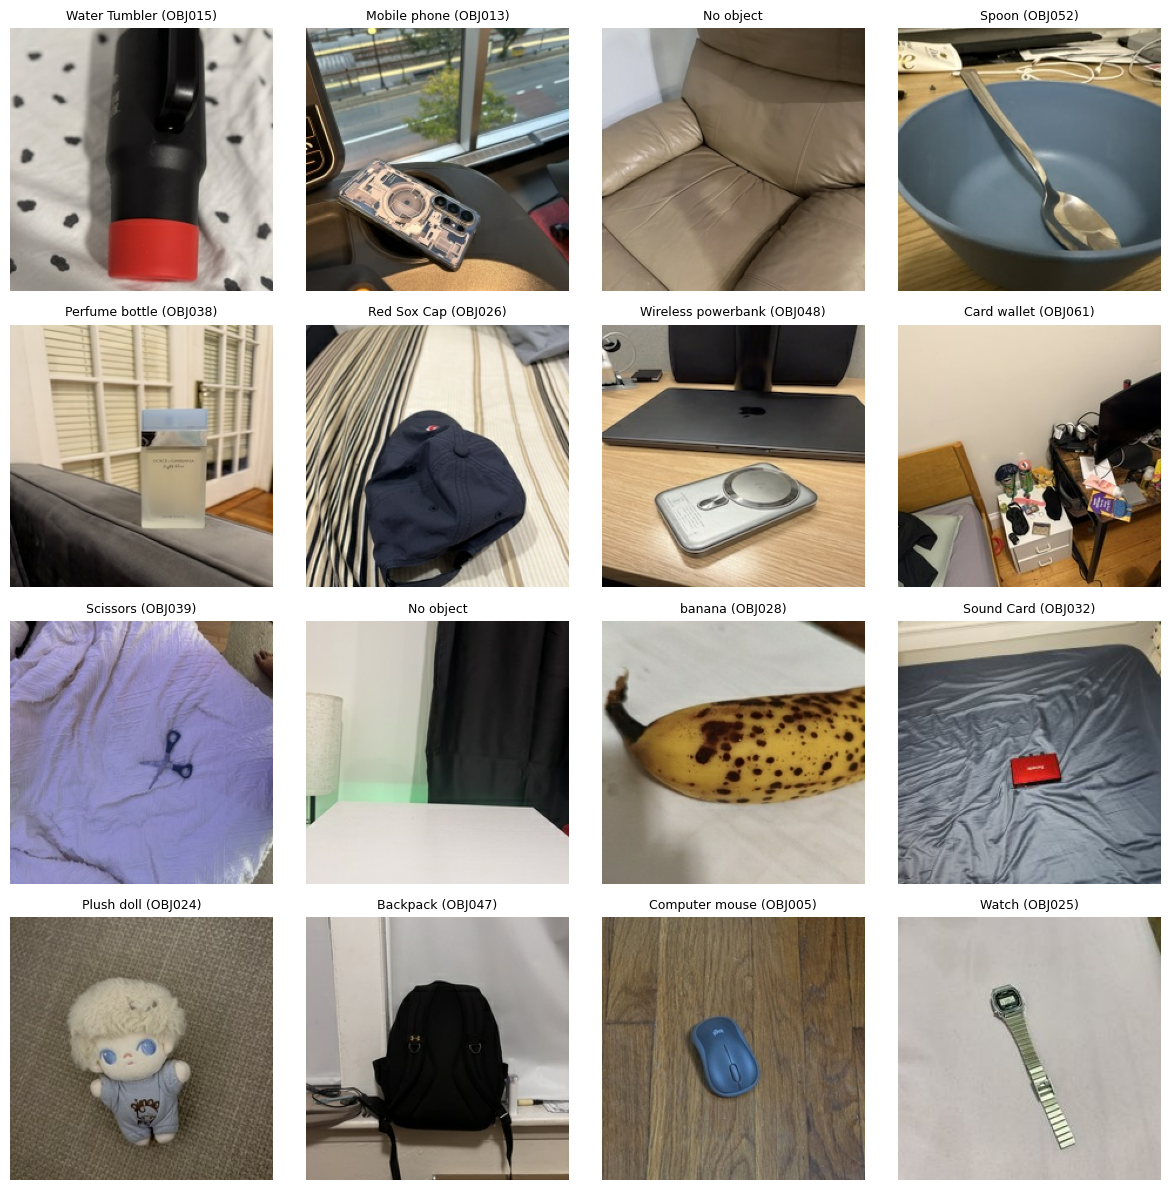

In [ ]:
import matplotlib.pyplot as plt

imgs, labels = next(iter(train_ds))
plt.figure(figsize=(12, 12))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(imgs[i].numpy().astype("uint8"))
    plt.title(DISPLAY_NAMES[labels[i]], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

Important points to note based on the sanity check:
* There is potential for scene-bias risk since students photographed objects in their own rooms, so a model could learn to recognize the room instead of the object. The background images and the "unseen-environment" holdout were designed to test exactly this.  
* Photos with multiple objects can contain other classes' objects:
  * OBJ061 - a card wallet in the same scene as a water bottle
  * OBJ052 - a spoon in a bowl
  Since the classification labels each image by its focal object, this should just act as minor label noise but will matter more for the next milestone.
* Some object classes are quite similar - there are three watches, three sets of rackets and bats, two power banks, two pairs of sunglasse and two wallets. We expect there to be some confusion within these groups.

## 5.0 Building Models
### 5.1 Building blocks: defaults, augmentation, optimizers

In [ ]:
import time
from tensorflow import keras
from tensorflow.keras import layers

# Every experiment starts from these; a config only lists what it changes
DEFAULTS = {
    # architecture
    "blocks": 3, "filters": 32, "convs_per_block": 1, "dense_units": 0,
    # regularization
    "batchnorm": False, "bn_momentum": 0.99, "dropout": 0.3, "augment": True,
    # optimization
    "optimizer": "adam", "lr": 1e-3, "epochs": 60, "patience": 10,
    "log": True,                   # False for smoke tests, so they don't pollute results
}

def make_augmentation():
    """Random transforms applied during training only (Keras disables them at inference)."""
    return keras.Sequential([
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.08, seed=SEED),
        layers.RandomZoom(0.15, seed=SEED),
        layers.RandomBrightness(0.15, value_range=(0, 255), seed=SEED),
        layers.RandomContrast(0.15, seed=SEED),
    ], name="augment")

def make_optimizer(name, lr):
    if name == "adam":    return keras.optimizers.Adam(lr)
    if name == "sgd":     return keras.optimizers.SGD(lr, momentum=0.9)
    if name == "rmsprop": return keras.optimizers.RMSprop(lr)
    raise ValueError(f"Unknown optimizer: {name}")

### 5.2 Model building functions

We are using GlobalAveravePooling2D instead of a Flatten layer. If we use Flatten on the final 28x28x128 feature map we would have 3.9mil weights going into the output layer. GAP needs about 5k. With approximately 67 training images per object, we significantly reduce the overfitting risk.

In [ ]:
def build_model(cfg):
    """Build an uncompiled CNN from a config. Input: raw 0–255 images. Output: class probabilities."""
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = make_augmentation()(inputs) if cfg["augment"] else inputs
    x = layers.Rescaling(1 / 255)(x)

    for b in range(cfg["blocks"]):
        f = cfg["filters"] * 2 ** b                         # 32 → 64 → 128 ...
        for _ in range(cfg["convs_per_block"]):
            x = layers.Conv2D(f, 3, padding="same", use_bias=not cfg["batchnorm"])(x)
            if cfg["batchnorm"]:
                x = layers.BatchNormalization(momentum=cfg["bn_momentum"])(x)
            x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    if cfg["dense_units"]:
        x = layers.Dense(cfg["dense_units"], activation="relu")(x)
    x = layers.Dropout(cfg["dropout"])(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inputs, outputs, name=cfg["name"])

### 5.3 Experimental config

We make sure the test set is never used here while ensuring our results are reproducible. The returned model at the end has the best weights since we are setting `restore_best_weights=True`.

In [ ]:
def run_experiment(overrides):
    """Train one config, log it to RESULTS_CSV, and return (best model, history, results row)."""
    cfg = {**DEFAULTS, **overrides}
    keras.backend.clear_session() # free GPU memory from previous runs
    keras.utils.set_random_seed(SEED) # consistent seed for reproducibility
    ckpt = MODELS_DIR / f"{cfg['name']}.keras"

    model = build_model(cfg)
    model.compile(optimizer=make_optimizer(cfg["optimizer"], cfg["lr"]),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=cfg["patience"], restore_best_weights=True),
        keras.callbacks.ModelCheckpoint(ckpt, monitor="val_loss", save_best_only=True),
    ]

    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=cfg["epochs"],
                        class_weight=CLASS_WEIGHTS, callbacks=callbacks, verbose=2).history

    best = int(np.argmin(history["val_loss"]))
    row = {
        "name": cfg["name"], "params": model.count_params(),
        "epochs_run": len(history["loss"]), "best_epoch": best + 1,
        "train_acc": round(history["accuracy"][best], 4),
        "val_acc": round(history["val_accuracy"][best], 4),
        "val_loss": round(history["val_loss"][best], 4),
        "minutes": round((time.time() - t0) / 60, 1),
        "config": json.dumps(cfg),
    }
    if cfg["log"]:
        pd.DataFrame([row]).to_csv(RESULTS_CSV, mode="a", header=not RESULTS_CSV.exists(), index=False)

    print({k: v for k, v in row.items() if k != "config"})
    return model, history, row

### 5.4 Smoke test

In [ ]:
_ = run_experiment({"name": "smoke_test", "epochs": 2, "log": False})

Epoch 1/2
158/158 - 12s - 73ms/step - accuracy: 0.0159 - loss: 4.2952 - val_accuracy: 0.0269 - val_loss: 4.2575
Epoch 2/2
158/158 - 10s - 63ms/step - accuracy: 0.0320 - loss: 4.1789 - val_accuracy: 0.0546 - val_loss: 4.1217
{'name': 'smoke_test', 'params': 102794, 'epochs_run': 2, 'best_epoch': 2, 'train_acc': 0.032, 'val_acc': 0.0546, 'val_loss': 4.1217, 'minutes': 0.4}


 Defining the various model setups we are testing:

In [ ]:
EXPERIMENTS = [
    {"name": "cnn_baseline"}, # 3 blocks, 32 filters, dropout 0.3, augmentation, Adam
    # Architecture
    {"name": "cnn_2blocks",     "blocks": 2},
   {"name": "cnn_4blocks",     "blocks": 4},
   {"name": "cnn_2conv",       "convs_per_block": 2},
   {"name": "cnn_dense256",    "dense_units": 256},
    # Regularization
   {"name": "cnn_bn",          "batchnorm": True},
    {"name": "cnn_dropout0.5",  "dropout": 0.5},
    {"name": "cnn_no_aug",      "augment": False},
    # Optimization
   {"name": "cnn_sgd",         "optimizer": "sgd", "lr": 1e-2},
  {"name": "cnn_rmsprop",     "optimizer": "rmsprop"},
]

### 5.4 Running the experiment with the baseline config first and then the variants

In [ ]:
model, history, row = run_experiment(EXPERIMENTS[0])

Epoch 1/60
158/158 - 10s - 66ms/step - accuracy: 0.0161 - loss: 4.2933 - val_accuracy: 0.0130 - val_loss: 4.2490
Epoch 2/60
158/158 - 8s - 54ms/step - accuracy: 0.0416 - loss: 4.1512 - val_accuracy: 0.0460 - val_loss: 4.0621
Epoch 3/60
158/158 - 9s - 55ms/step - accuracy: 0.0617 - loss: 3.9602 - val_accuracy: 0.0911 - val_loss: 3.9191
Epoch 4/60
158/158 - 9s - 55ms/step - accuracy: 0.0899 - loss: 3.8119 - val_accuracy: 0.1084 - val_loss: 3.8089
Epoch 5/60
158/158 - 9s - 55ms/step - accuracy: 0.1217 - loss: 3.6572 - val_accuracy: 0.1336 - val_loss: 3.6904
Epoch 6/60
158/158 - 9s - 54ms/step - accuracy: 0.1375 - loss: 3.5323 - val_accuracy: 0.1787 - val_loss: 3.5504
Epoch 7/60
158/158 - 9s - 54ms/step - accuracy: 0.1697 - loss: 3.3964 - val_accuracy: 0.1683 - val_loss: 3.5482
Epoch 8/60
158/158 - 8s - 54ms/step - accuracy: 0.1699 - loss: 3.3582 - val_accuracy: 0.2029 - val_loss: 3.4113
Epoch 9/60
158/158 - 8s - 54ms/step - accuracy: 0.1922 - loss: 3.2511 - val_accuracy: 0.2003 - val_loss

In [ ]:
COMBINED = [
    {"name": "cnn_bn_m0.9",     "batchnorm": True, "bn_momentum": 0.9},
    {"name": "cnn_combo",       "blocks": 4, "convs_per_block": 2, "dense_units": 256,
                                "epochs": 100, "patience": 15},
    {"name": "cnn_combo_noaug", "blocks": 4, "convs_per_block": 2, "dense_units": 256,
                                "augment": False, "epochs": 100, "patience": 15},
    {"name": "cnn_combo_bn",    "blocks": 4, "convs_per_block": 2, "dense_units": 256,
                                "batchnorm": True, "bn_momentum": 0.9, "epochs": 100, "patience": 15},
]

ALL_RUNS = EXPERIMENTS + COMBINED
done = set(pd.read_csv(RESULTS_CSV)["name"]) if RESULTS_CSV.exists() else set()
for exp in ALL_RUNS:
    if exp["name"] in done:
        print(f"Skipping {exp['name']} (already logged)")
        continue
    run_experiment(exp)

Skipping cnn_baseline (already logged)
Epoch 1/60
158/158 - 9s - 55ms/step - accuracy: 0.0133 - loss: 4.3042 - val_accuracy: 0.0147 - val_loss: 4.2961
Epoch 2/60
158/158 - 7s - 44ms/step - accuracy: 0.0235 - loss: 4.2694 - val_accuracy: 0.0278 - val_loss: 4.2285
Epoch 3/60
158/158 - 7s - 44ms/step - accuracy: 0.0382 - loss: 4.1712 - val_accuracy: 0.0512 - val_loss: 4.1385
Epoch 4/60
158/158 - 7s - 44ms/step - accuracy: 0.0477 - loss: 4.0796 - val_accuracy: 0.0789 - val_loss: 4.0498
Epoch 5/60
158/158 - 7s - 44ms/step - accuracy: 0.0641 - loss: 3.9939 - val_accuracy: 0.0919 - val_loss: 4.0051
Epoch 6/60
158/158 - 7s - 44ms/step - accuracy: 0.0690 - loss: 3.9404 - val_accuracy: 0.0737 - val_loss: 3.9542
Epoch 7/60
158/158 - 7s - 44ms/step - accuracy: 0.0800 - loss: 3.8791 - val_accuracy: 0.0876 - val_loss: 3.9049
Epoch 8/60
158/158 - 7s - 44ms/step - accuracy: 0.0909 - loss: 3.8348 - val_accuracy: 0.1188 - val_loss: 3.8473
Epoch 9/60
158/158 - 7s - 44ms/step - accuracy: 0.0971 - loss: 3.

In [ ]:
results = pd.read_csv(RESULTS_CSV).drop(columns="config")
results.sort_values("val_acc", ascending=False).reset_index(drop=True)

,name,params,epochs_run,best_epoch,train_acc,val_acc,val_loss,minutes
0,cnn_4blocks,407434,51,41,0.7315,0.6331,1.7447,8.1
1,cnn_combo_bn,1259946,66,51,0.7979,0.5924,1.9259,52.8
2,cnn_no_aug,102794,60,59,0.5691,0.5533,2.1790,10.0
3,cnn_2conv,296554,60,58,0.5922,0.5403,1.9911,21.6
4,cnn_dense256,145290,46,36,0.5914,0.5074,2.2064,6.6
5,cnn_baseline,102794,60,54,0.4828,0.4926,2.3405,8.6
6,cnn_bn,103466,54,44,0.4609,0.4224,2.5255,17.2
7,cnn_sgd,102794,60,60,0.3839,0.3894,2.5208,8.4
8,cnn_dropout0.5,102794,50,40,0.3698,0.3842,2.6264,7.1
9,cnn_rmsprop,102794,37,27,0.3121,0.2810,3.0883,5.2


## 6.1 Load the candidates and a prediction helper

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt

CANDIDATES = ["cnn_4blocks", "cnn_combo_bn", "cnn_no_aug"]
BEST = "cnn_4blocks"                     # chosen on validation accuracy, before looking at test

models = {n: keras.models.load_model(MODELS_DIR / f"{n}.keras") for n in CANDIDATES}

def predict_split(model, split):
    """Return (rows of that split, predicted probabilities) in matching order."""
    sub = df[df["split"] == split].reset_index(drop=True)
    probs = model.predict(make_ds(split), verbose=0)     # unshuffled, so same order as sub
    return sub, probs

## 6.2 Comparison table on the test set

In [ ]:
NO_OBJ = label_to_idx["no_object"]
rows, preds = [], {}

for name, model in models.items():
    sub, probs = predict_split(model, "test")
    y_true = sub["label"].map(label_to_idx).values
    y_pred = probs.argmax(1)
    preds[name] = (sub, y_true, y_pred, probs)

    bg = sub["is_bg"].values
    own_obj = sub["owner"].map(label_to_idx).values      # object of the student who took each photo
    top3 = np.mean([t in np.argsort(p)[-3:] for t, p in zip(y_true, probs)])
    _, u_probs = predict_split(model, "unseen")

    rows.append({
        "model":            name,
        "test_acc":         (y_pred == y_true).mean(),
        "top3_acc":         top3,
        "macro_f1":         f1_score(y_true, y_pred, average="macro", zero_division=0),
        "object_acc":       (y_pred[~bg] == y_true[~bg]).mean(),
        "bg_correct":       (y_pred[bg] == NO_OBJ).mean(),
        "bg_as_own_object": (y_pred[bg] == own_obj[bg]).mean(),
        "unseen_correct":   f"{(u_probs.argmax(1) == label_to_idx['OBJ042']).sum()}/9",
    })

eval_df = pd.DataFrame(rows).round(3)
eval_df.to_csv(PROJECT / f"eval_{DATA_VERSION}.csv", index=False)
eval_df

,model,test_acc,top3_acc,macro_f1,object_acc,bg_correct,bg_as_own_object,unseen_correct
0,cnn_4blocks,0.644,0.740,0.648,0.678,0.017,0.190,0/9
1,cnn_combo_bn,0.597,0.744,0.614,0.615,0.259,0.155,0/9
2,cnn_no_aug,0.520,0.683,0.514,0.547,0.000,0.276,0/9


## 6.3 Hardest and easiest classes (best model)

In [ ]:
sub, y_true, y_pred, probs = preds[BEST]
report = classification_report(y_true, y_pred, labels=range(NUM_CLASSES), target_names=DISPLAY_NAMES,
                               output_dict=True, zero_division=0)
per_class = pd.DataFrame(report).T.iloc[:NUM_CLASSES][["precision", "recall", "f1-score", "support"]].round(2)
per_class.to_csv(PROJECT / f"per_class_{BEST}_{DATA_VERSION}.csv")

print("Hardest 10 classes"); display(per_class.sort_values("f1-score").head(10))
print("Easiest 10 classes"); display(per_class.sort_values("f1-score", ascending=False).head(10))

Hardest 10 classes


,precision,recall,f1-score,support
No object,0.25,0.02,0.03,58.0
Card wallet (OBJ061),0.14,0.07,0.09,15.0
Perfume bottle (OBJ038),0.18,0.13,0.15,15.0
Toy Car (OBJ004),0.17,0.13,0.15,15.0
Table Tennis Racket (OBJ034),0.33,0.13,0.19,15.0
Controller (OBJ017),0.33,0.13,0.19,15.0
Mobile phone (OBJ013),0.15,0.33,0.20,15.0
Wayfarer Sunglasses (OBJ045),0.18,0.33,0.23,15.0
Wireless powerbank (OBJ048),0.27,0.27,0.27,15.0
Power Bank (OBJ057),0.40,0.27,0.32,15.0


Easiest 10 classes


,precision,recall,f1-score,support
Nike sneakers (OBJ010),0.94,1.00,0.97,15.0
Rubiks cube (OBJ018),0.94,1.00,0.97,15.0
Orange (OBJ029),0.94,1.00,0.97,15.0
hair oil (OBJ066),1.00,0.93,0.97,15.0
Table fan (OBJ041),0.88,1.00,0.94,15.0
Clutcher (OBJ040),0.88,1.00,0.94,15.0
Moisturizer (OBJ053),1.00,0.87,0.93,15.0
Basketball (OBJ001),0.93,0.93,0.93,15.0
Sound Card (OBJ032),0.83,1.00,0.91,15.0
banana (OBJ028),0.83,1.00,0.91,15.0


## 6.4 Confusion matrix and most-confused pairs

,true,predicted,count
75,Bracelet (OBJ023),Wayfarer Sunglasses (OBJ045),7
138,Swimming Goggels (OBJ043),Hairbrush (OBJ050),7
248,No object,Watch (OBJ025),6
166,tissue (OBJ051),Comb (OBJ059),5
10,Toy Car (OBJ004),Wayfarer Sunglasses (OBJ045),5
177,Purse (OBJ054),Trader Joe's Bag (OBJ056),5
64,Controller (OBJ017),Wayfarer Sunglasses (OBJ045),5
246,No object,Airpod (OBJ020),5
185,Power Bank (OBJ057),RGB Projector (OBJ064),4
52,Water Tumbler (OBJ015),Wireless powerbank (OBJ048),4


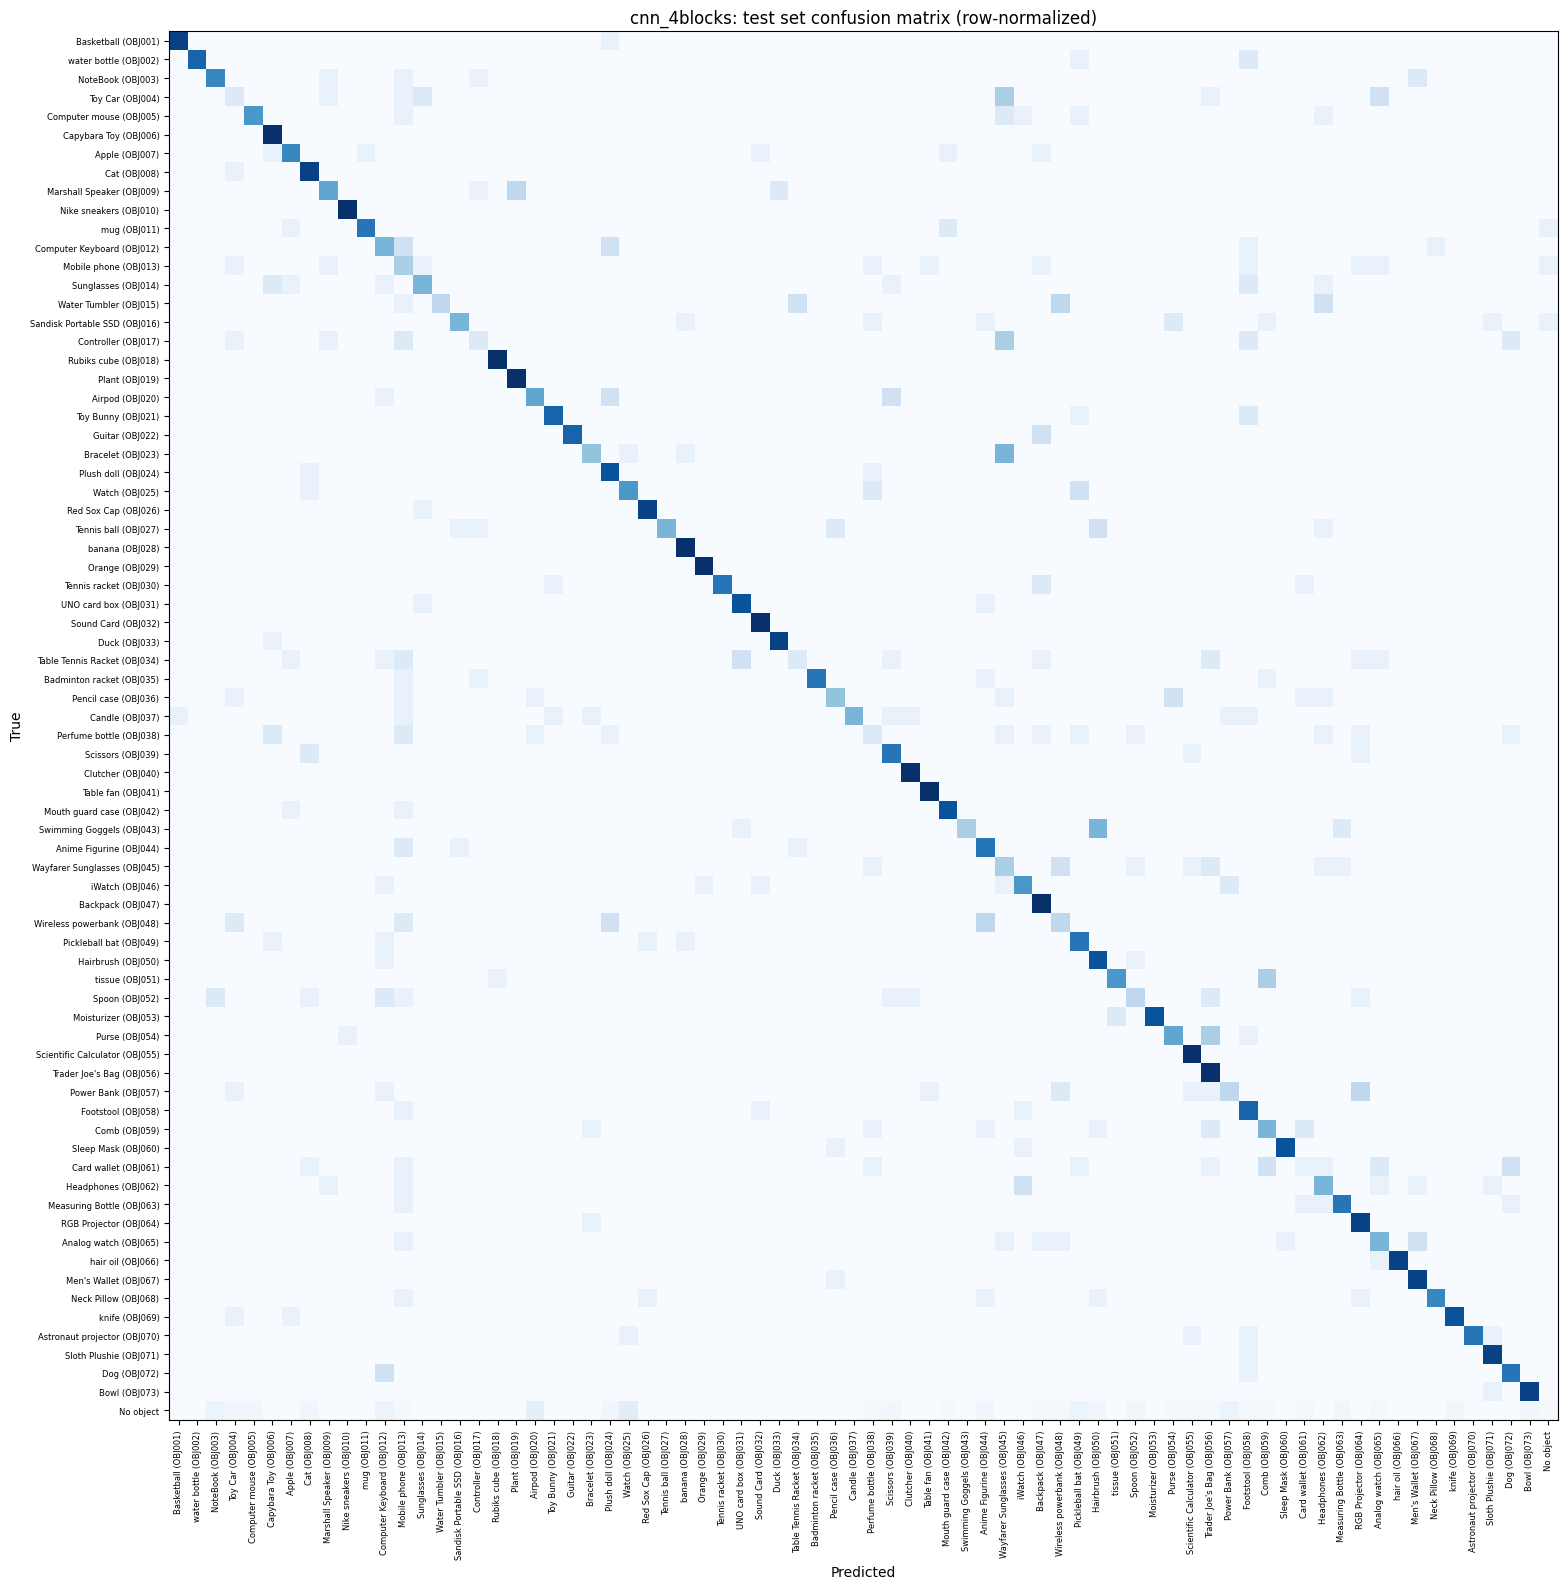

In [ ]:
cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))

# Most common mistakes, as a readable table
off = cm.copy()
np.fill_diagonal(off, 0)
pairs = [(DISPLAY_NAMES[i], DISPLAY_NAMES[j], off[i, j]) for i, j in zip(*np.nonzero(off))]
top_pairs = pd.DataFrame(pairs, columns=["true", "predicted", "count"]).sort_values("count", ascending=False)
display(top_pairs.head(15))

# Full matrix, row-normalized (diagonal = recall per class)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(16, 16))
ax.imshow(cm_norm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(DISPLAY_NAMES, rotation=90, fontsize=6)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(DISPLAY_NAMES, fontsize=6)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"{BEST}: test set confusion matrix (row-normalized)")
plt.tight_layout()
plt.savefig(PROJECT / f"confusion_{BEST}_{DATA_VERSION}.png", dpi=150)
plt.show()

## 6.5 Your unseen-environment images

The hold-set as mentioned earlier in this notebook was given to our final CNN model. We can see that 5/9 images were classified as OBJ040 which was a clutcher. 2/9 images were classified as a pickleball bat and the other 2/9 images were classified as an RGB projector. Not a single one of these images were classified correctly by our final model which was an interesting finding.

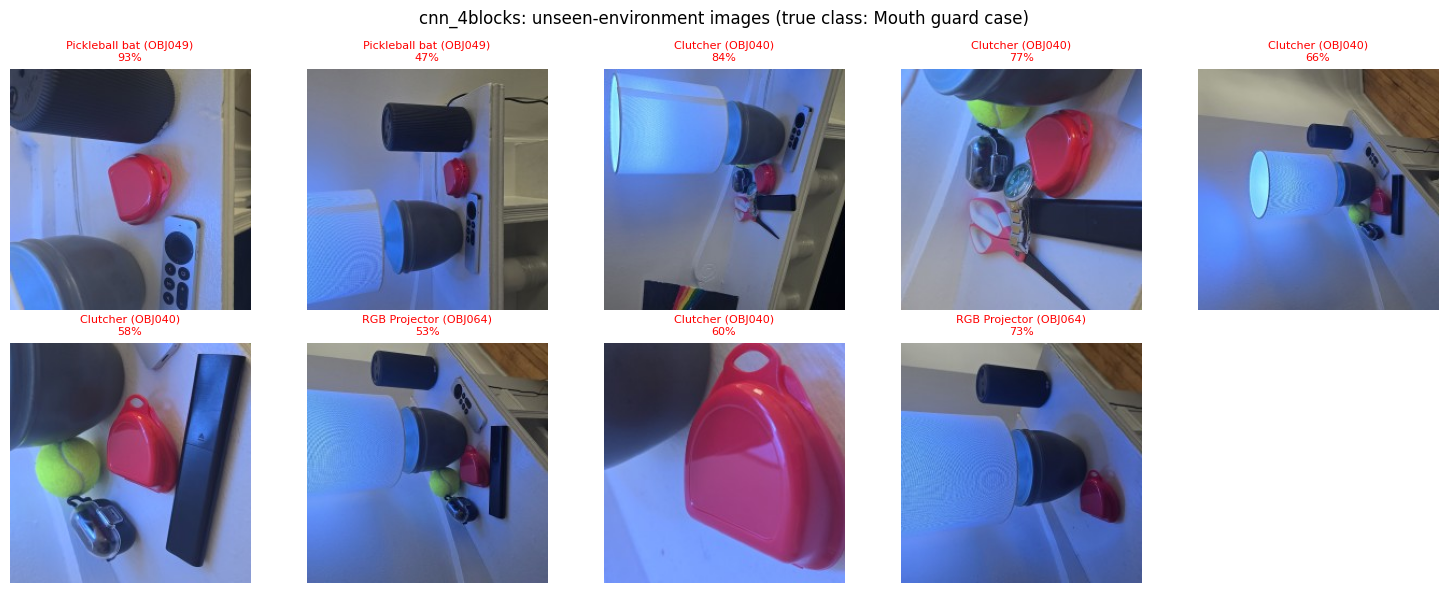

In [ ]:
u_sub, u_probs = predict_split(models[BEST], "unseen")
plt.figure(figsize=(15, 6))
for i, r in u_sub.iterrows():
    k = u_probs[i].argmax()
    plt.subplot(2, 5, i + 1)
    plt.imshow(plt.imread(LOCAL_DATA / r["path"]))
    plt.title(f"{DISPLAY_NAMES[k]}\n{u_probs[i][k]:.0%}", fontsize=8,
              color="green" if class_names[k] == "OBJ042" else "red")
    plt.axis("off")
plt.suptitle(f"{BEST}: unseen-environment images (true class: Mouth guard case)")
plt.tight_layout()
plt.savefig(PROJECT / f"unseen_{BEST}_{DATA_VERSION}.png", dpi=150)
plt.show()

## 7.0 Conclusion

We built a validated, versioned data pipeline for a class-collected dataset with multiple problems, then designed and compared 14 CNNs trained from scratch. The experiments we ran would vary one aspect at at a time. An early pilot of the preliminary dataset showed the models were underfitting and that capacity was the main bottleneck. Those findings held on the final 73-object dataset, where a 4-block CNN performed best (63% accuracy vs 49% for the baseline and 1.4% for chance). We also found that batch normalization was unnecessary for shallow networks but essential for deeper ones and that the largest model overfit. Evaluation on held-out test data, empty-background images, and photos from unseen environments confirms the choice of model.